# Layer-wise Classifier Experiment - DeBERTa v3

**Goal**: Test how discriminative power evolves across ALL encoder layers for RTE classification.

**Approach**:
1. Extract features from ALL encoder layers using different pooling strategies
2. Train simple classifiers on each layer's features
3. Compare performance across all layers, pooling strategies, and classifiers
4. Identify which layer depth provides the best discriminative features

**Model**: `RazyDave/deberta-v3-base-finetuned-rte` (12 encoder layers)

## Setup

In [73]:
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification

from features_extraction import (
    FeaturesExtraction,
    ExtractionConfig,
    setup_logging,
)

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

setup_logging(level="INFO")
print("✓ Setup complete")

✓ Setup complete


## Load Model and Data

In [74]:
# Load DeBERTa-v3-base fine-tuned on RTE
model_name = "RazyDave/deberta-v3-base-finetuned-rte"

print(f"Loading: {model_name}")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

print(f"Model: {model.__class__.__name__}")
print(f"Hidden size (H): {model.config.hidden_size}")
print(f"Num layers: {model.config.num_hidden_layers}")

Loading: RazyDave/deberta-v3-base-finetuned-rte
Model: DebertaV2ForSequenceClassification
Hidden size (H): 768
Num layers: 12


In [75]:
# Load RTE dataset (train + validation)
train_dataset = load_dataset("glue", "rte", split="train")
val_dataset = load_dataset("glue", "rte", split="validation")

print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"\nLabel distribution (train): {np.bincount([x['label'] for x in train_dataset])}")
print(f"Label distribution (val): {np.bincount([x['label'] for x in val_dataset])}")

Train samples: 2490
Validation samples: 277

Label distribution (train): [1249 1241]
Label distribution (val): [146 131]


## Define Tokenization Function

In [76]:
def tokenize_fn(tokenizer, batch, max_length):
    return tokenizer(
        batch["sentence1"],
        batch["sentence2"],
        padding="longest",
        truncation=True,
        max_length=max_length,
    )

## Extract Features from ALL Encoder Layers

We'll extract features using different pooling strategies:
- **mean**: Average pooling (baseline)
- **cls**: CLS token only
- **max**: Max pooling

Features will be extracted from ALL encoder layers to see how discriminative power evolves through the network depth.

In [77]:
# Initialize extractor
extractor = FeaturesExtraction(model, tokenizer)

MAX_LENGTH = 128
BATCH_SIZE = 16

# Pooling strategies to test
POOLING_STRATEGIES = ["mean", "cls", "max"]

print(f"Will extract features from ALL layers for each pooling strategy")
print(f"Pooling strategies: {POOLING_STRATEGIES}")

2026-02-12 13:57:00 [INFO] features_extraction.core: Initialized FeaturesExtraction with model=DebertaV2ForSequenceClassification, tokenizer=DebertaV2TokenizerFast


Will extract features from ALL layers for each pooling strategy
Pooling strategies: ['mean', 'cls', 'max']


In [78]:
# Store all extracted features
features_by_pooling = {}

for pooling in POOLING_STRATEGIES:
    print(f"\n{'='*70}")
    print(f"Extracting with {pooling.upper()} pooling")
    print(f"{'='*70}")
    
    # Extract from TRAIN set
    print("\nTrain set...")
    train_features_dict, train_labels = extractor.extract_all_layers(
        dataset=train_dataset,
        tokenize_fn=tokenize_fn,
        config=ExtractionConfig(
            batch_size=BATCH_SIZE,
            max_length=MAX_LENGTH,
            pooling=pooling,
            return_numpy=True,
        ),
    )
    
    # Extract from VALIDATION set
    print("\nValidation set...")
    val_features_dict, val_labels = extractor.extract_all_layers(
        dataset=val_dataset,
        tokenize_fn=tokenize_fn,
        config=ExtractionConfig(
            batch_size=BATCH_SIZE,
            max_length=MAX_LENGTH,
            pooling=pooling,
            return_numpy=True,
        ),
    )
    
    features_by_pooling[pooling] = {
        'train': (train_features_dict, train_labels),
        'val': (val_features_dict, val_labels),
    }
    
    # Show layer info
    layer_names = list(train_features_dict.keys())
    print(f"\n✓ Extracted {len(layer_names)} layers")
    first_layer_shape = train_features_dict[layer_names[0]].shape
    print(f"  Shape per layer: {first_layer_shape}")
    print(f"  Feature dimension: {first_layer_shape[1]}")

print("\n✓ All extractions complete!")

2026-02-12 13:57:00 [INFO] features_extraction.utils: Starting extract_all_layers
2026-02-12 13:57:00 [INFO] features_extraction.device: Auto-selected Apple MPS device



Extracting with MEAN pooling

Train set...


2026-02-12 13:57:00 [INFO] features_extraction.tokenizer: Tokenizing dataset: keeping {'labels', 'label'}, removing 3 columns
2026-02-12 13:57:00 [INFO] features_extraction.tokenizer: Tokenization complete. Dataset has 2490 examples, columns: ['label', 'input_ids', 'token_type_ids', 'attention_mask']
2026-02-12 13:57:00 [INFO] features_extraction.core: Extracting all layers with pooling=mean
2026-02-12 13:57:00 [INFO] features_extraction.core: Found 13 layers: ['input', 'layer_0', 'layer_1']...embeddings
2026-02-12 13:57:31 [INFO] features_extraction.utils: Completed extract_all_layers in 30.79s
2026-02-12 13:57:31 [INFO] features_extraction.utils: Starting extract_all_layers
2026-02-12 13:57:31 [INFO] features_extraction.device: Auto-selected Apple MPS device
2026-02-12 13:57:31 [INFO] features_extraction.tokenizer: Tokenizing dataset: keeping {'labels', 'label'}, removing 3 columns
2026-02-12 13:57:31 [INFO] features_extraction.tokenizer: Tokenization complete. Dataset has 277 exampl


Validation set...


2026-02-12 13:57:34 [INFO] features_extraction.utils: Completed extract_all_layers in 3.41s
2026-02-12 13:57:34 [INFO] features_extraction.utils: Starting extract_all_layers
2026-02-12 13:57:34 [INFO] features_extraction.device: Auto-selected Apple MPS device
2026-02-12 13:57:34 [INFO] features_extraction.tokenizer: Tokenizing dataset: keeping {'labels', 'label'}, removing 3 columns
2026-02-12 13:57:34 [INFO] features_extraction.tokenizer: Tokenization complete. Dataset has 2490 examples, columns: ['label', 'input_ids', 'token_type_ids', 'attention_mask']
2026-02-12 13:57:34 [INFO] features_extraction.core: Extracting all layers with pooling=cls
2026-02-12 13:57:34 [INFO] features_extraction.core: Found 13 layers: ['input', 'layer_0', 'layer_1']...embeddings


...


✓ Extracted 13 layers
  Shape per layer: (2490, 768)
  Feature dimension: 768

Extracting with MAX pooling

Train set...


2026-02-12 13:58:46 [INFO] features_extraction.utils: Completed extract_all_layers in 38.13s
2026-02-12 13:58:46 [INFO] features_extraction.utils: Starting extract_all_layers
2026-02-12 13:58:46 [INFO] features_extraction.device: Auto-selected Apple MPS device
2026-02-12 13:58:46 [INFO] features_extraction.tokenizer: Tokenizing dataset: keeping {'labels', 'label'}, removing 3 columns
2026-02-12 13:58:46 [INFO] features_extraction.tokenizer: Tokenization complete. Dataset has 277 examples, columns: ['label', 'input_ids', 'token_type_ids', 'attention_mask']
2026-02-12 13:58:46 [INFO] features_extraction.core: Extracting all layers with pooling=max
2026-02-12 13:58:46 [INFO] features_extraction.core: Found 13 layers: ['input', 'layer_0', 'layer_1']...embeddings



Validation set...


2026-02-12 13:58:50 [INFO] features_extraction.utils: Completed extract_all_layers in 4.46s



✓ Extracted 13 layers
  Shape per layer: (2490, 768)
  Feature dimension: 768

✓ All extractions complete!


## Identify ALL Encoder Layers

In [79]:
# Get layer names from any pooling (they're all the same)
all_layer_names = list(features_by_pooling['mean']['train'][0].keys())

print(f"All extracted layers: {all_layer_names}")

# Filter encoder layers (exclude 'input' and 'embeddings')
encoder_layers = [name for name in all_layer_names if name.startswith('layer_')]
print(f"\nEncoder layers ({len(encoder_layers)} total): {encoder_layers}")

# We'll test ALL encoder layers
target_layers = encoder_layers
print(f"\n🎯 Target layers: ALL {len(target_layers)} encoder layers")

All extracted layers: ['input', 'layer_0', 'layer_1', 'layer_2', 'layer_3', 'layer_4', 'layer_5', 'layer_6', 'layer_7', 'layer_8', 'layer_9', 'layer_10', 'embeddings']

Encoder layers (11 total): ['layer_0', 'layer_1', 'layer_2', 'layer_3', 'layer_4', 'layer_5', 'layer_6', 'layer_7', 'layer_8', 'layer_9', 'layer_10']

🎯 Target layers: ALL 11 encoder layers


## Train Classifiers on Each Layer

We'll train 3 types of classifiers:
1. **Logistic Regression** (simple linear model)
2. **Linear SVM** (maximum margin classifier)
3. **Random Forest** (non-linear ensemble)

For each combination of:
- Pooling strategy (mean, cls, max)
- Layer (ALL encoder layers - layer_0 through layer_11)
- Classifier type

This will take some time as we're testing all layers!

In [80]:
# Define classifiers
CLASSIFIERS = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Linear SVM': LinearSVC(max_iter=5000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

print(f"Classifiers: {list(CLASSIFIERS.keys())}")
print(f"Pooling strategies: {POOLING_STRATEGIES}")
print(f"Layers to test: {target_layers}")
print(f"\nTotal experiments: {len(CLASSIFIERS) * len(POOLING_STRATEGIES) * len(target_layers)}")

Classifiers: ['Logistic Regression', 'Linear SVM', 'Random Forest']
Pooling strategies: ['mean', 'cls', 'max']
Layers to test: ['layer_0', 'layer_1', 'layer_2', 'layer_3', 'layer_4', 'layer_5', 'layer_6', 'layer_7', 'layer_8', 'layer_9', 'layer_10']

Total experiments: 99


In [81]:
# Store results
results = []

for pooling in POOLING_STRATEGIES:
    train_features_dict, train_labels = features_by_pooling[pooling]['train']
    val_features_dict, val_labels = features_by_pooling[pooling]['val']
    
    for layer_name in target_layers:
        # Get features for this layer
        X_train = train_features_dict[layer_name]
        y_train = train_labels
        X_val = val_features_dict[layer_name]
        y_val = val_labels
        
        print(f"\n{'='*70}")
        print(f"Pooling: {pooling.upper()} | Layer: {layer_name}")
        print(f"{'='*70}")
        print(f"Train shape: {X_train.shape}")
        print(f"Val shape: {X_val.shape}")
        
        for clf_name, clf in CLASSIFIERS.items():
            print(f"\n  Training {clf_name}...")
            
            # Clone classifier for each experiment
            from sklearn.base import clone
            clf_instance = clone(clf)
            
            # Train
            clf_instance.fit(X_train, y_train)
            
            # Predict on validation set
            y_pred = clf_instance.predict(X_val)
            
            # Compute metrics
            accuracy = accuracy_score(y_val, y_pred)
            f1 = f1_score(y_val, y_pred, average='weighted')
            
            print(f"    Accuracy: {accuracy:.4f}")
            print(f"    F1 (weighted): {f1:.4f}")
            
            # Store results
            # Extract layer number for easier analysis
            layer_num = int(layer_name.split('_')[1]) if 'layer_' in layer_name else -1
            
            results.append({
                'pooling': pooling,
                'layer': layer_name,
                'layer_num': layer_num,
                'classifier': clf_name,
                'accuracy': accuracy,
                'f1_score': f1,
                'train_samples': len(X_train),
                'val_samples': len(X_val),
                'feature_dim': X_train.shape[1],
            })

# Convert to DataFrame
results_df = pd.DataFrame(results)
print("\n✓ All experiments complete!")
print(f"\nTotal experiments: {len(results_df)}")


Pooling: MEAN | Layer: layer_0
Train shape: (2490, 768)
Val shape: (277, 768)

  Training Logistic Regression...
    Accuracy: 0.5523
    F1 (weighted): 0.5526

  Training Linear SVM...
    Accuracy: 0.5199
    F1 (weighted): 0.5202

  Training Random Forest...
    Accuracy: 0.5560
    F1 (weighted): 0.5547

Pooling: MEAN | Layer: layer_1
Train shape: (2490, 768)
Val shape: (277, 768)

  Training Logistic Regression...
    Accuracy: 0.5162
    F1 (weighted): 0.5166

  Training Linear SVM...
    Accuracy: 0.5235
    F1 (weighted): 0.5231

  Training Random Forest...
    Accuracy: 0.5162
    F1 (weighted): 0.5158

Pooling: MEAN | Layer: layer_2
Train shape: (2490, 768)
Val shape: (277, 768)

  Training Logistic Regression...
    Accuracy: 0.5054
    F1 (weighted): 0.5056

  Training Linear SVM...
    Accuracy: 0.5054
    F1 (weighted): 0.5058

  Training Random Forest...
    Accuracy: 0.5199
    F1 (weighted): 0.5189

Pooling: MEAN | Layer: layer_3
Train shape: (2490, 768)
Val shape: (2

## Results Summary

In [82]:
# Display all results
print("\n" + "="*70)
print("RESULTS SUMMARY")
print("="*70)

# Sort by accuracy
results_sorted = results_df.sort_values('accuracy', ascending=False)
print("\nTop 10 configurations by accuracy:")
print(results_sorted[['pooling', 'layer', 'classifier', 'accuracy', 'f1_score']].head(10).to_string(index=False))

print("\n" + "-"*70)
print("Average performance by pooling strategy:")
print(results_df.groupby('pooling')[['accuracy', 'f1_score']].mean().to_string())

print("\n" + "-"*70)
print("Average performance by layer:")
print(results_df.groupby('layer')[['accuracy', 'f1_score']].mean().sort_values('accuracy', ascending=False).head(12).to_string())

print("\n" + "-"*70)
print("Average performance by classifier:")
print(results_df.groupby('classifier')[['accuracy', 'f1_score']].mean().to_string())


RESULTS SUMMARY

Top 10 configurations by accuracy:
pooling    layer          classifier  accuracy  f1_score
    max layer_10          Linear SVM  0.844765  0.844838
   mean layer_10 Logistic Regression  0.841155  0.841246
   mean  layer_9 Logistic Regression  0.837545  0.837664
    max  layer_9 Logistic Regression  0.837545  0.837621
    max  layer_9       Random Forest  0.833935  0.834056
    cls layer_10          Linear SVM  0.830325  0.830444
    max layer_10       Random Forest  0.830325  0.830436
    max layer_10 Logistic Regression  0.830325  0.830405
    cls layer_10 Logistic Regression  0.826715  0.826837
   mean layer_10       Random Forest  0.823105  0.823188

----------------------------------------------------------------------
Average performance by pooling strategy:
         accuracy  f1_score
pooling                    
cls      0.599716  0.560177
max      0.614375  0.614068
mean     0.632535  0.632435

------------------------------------------------------------------

## Visualizations

In [83]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)

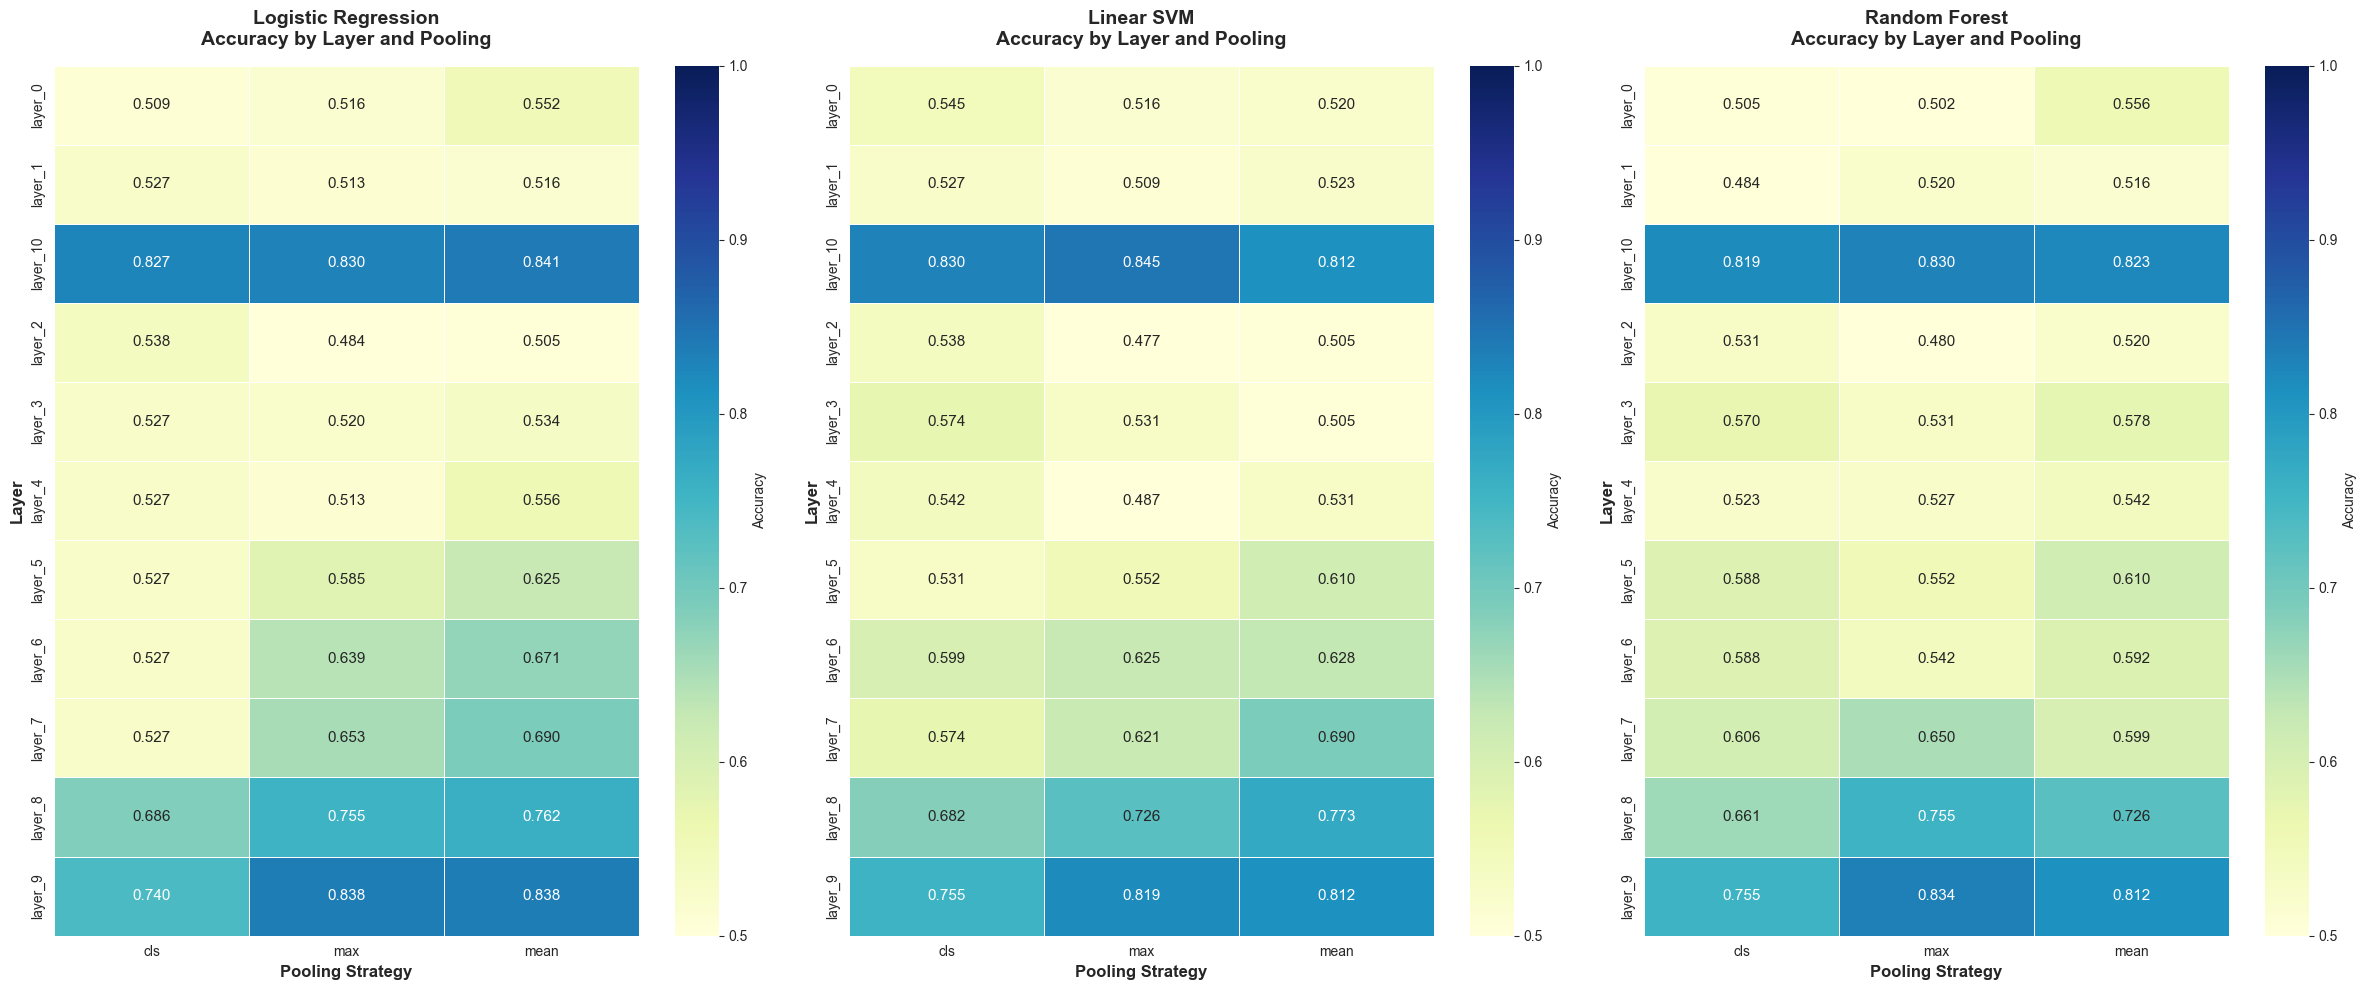

In [84]:
# 1. Heatmap: Accuracy by Layer and Pooling (for each classifier)
# Improved with larger figure and better font sizes
fig, axes = plt.subplots(1, 3, figsize=(24, 10))

for idx, clf_name in enumerate(CLASSIFIERS.keys()):
    clf_results = results_df[results_df['classifier'] == clf_name]
    
    # Pivot for heatmap (layers as rows, pooling as columns)
    pivot = clf_results.pivot(index='layer', columns='pooling', values='accuracy')
    
    # Create heatmap with larger annotations
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu', ax=axes[idx], 
                vmin=0.5, vmax=1.0, cbar_kws={'label': 'Accuracy'},
                annot_kws={'size': 11}, linewidths=0.5)
    axes[idx].set_title(f'{clf_name}\nAccuracy by Layer and Pooling', 
                       fontsize=14, fontweight='bold', pad=15)
    axes[idx].set_xlabel('Pooling Strategy', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Layer', fontsize=12, fontweight='bold')
    axes[idx].tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

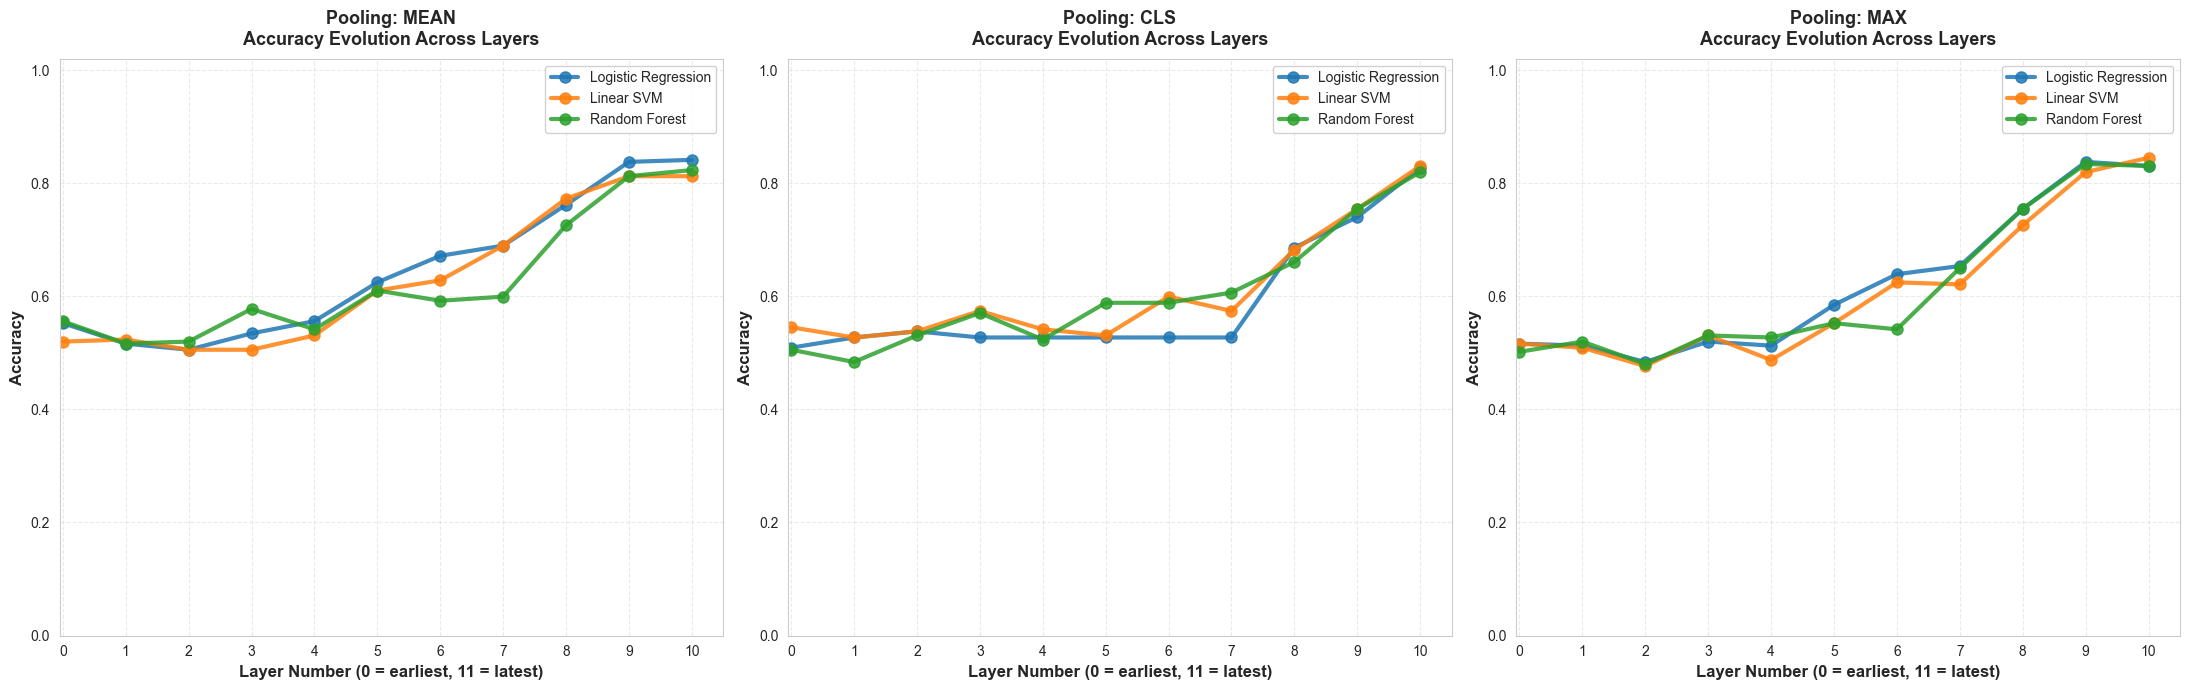

In [85]:
# 2. Line plot: Performance across ALL layers (shows layer depth evolution)
# This is the KEY visualization - shows trends clearly
fig, axes = plt.subplots(1, len(POOLING_STRATEGIES), figsize=(22, 7))

for idx, pooling in enumerate(POOLING_STRATEGIES):
    pooling_results = results_df[results_df['pooling'] == pooling]
    
    for clf_name in CLASSIFIERS.keys():
        clf_data = pooling_results[pooling_results['classifier'] == clf_name].sort_values('layer_num')
        axes[idx].plot(clf_data['layer_num'], clf_data['accuracy'], 
                      marker='o', label=clf_name, linewidth=3, markersize=8, alpha=0.85)
    
    axes[idx].set_xlabel('Layer Number (0 = earliest, 11 = latest)', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    axes[idx].set_title(f'Pooling: {pooling.upper()}\nAccuracy Evolution Across Layers', 
                       fontsize=13, fontweight='bold', pad=10)
    axes[idx].legend(fontsize=10, loc='best', framealpha=0.9)
    axes[idx].set_xlim([-0.05, len(encoder_layers) - 0.5])  # Add padding to x-axis
    axes[idx].set_ylim([0, 1.02])  # Add padding to y-axis
    axes[idx].grid(True, alpha=0.4, linestyle='--')
    axes[idx].set_xticks(range(len(encoder_layers)))
    axes[idx].tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()


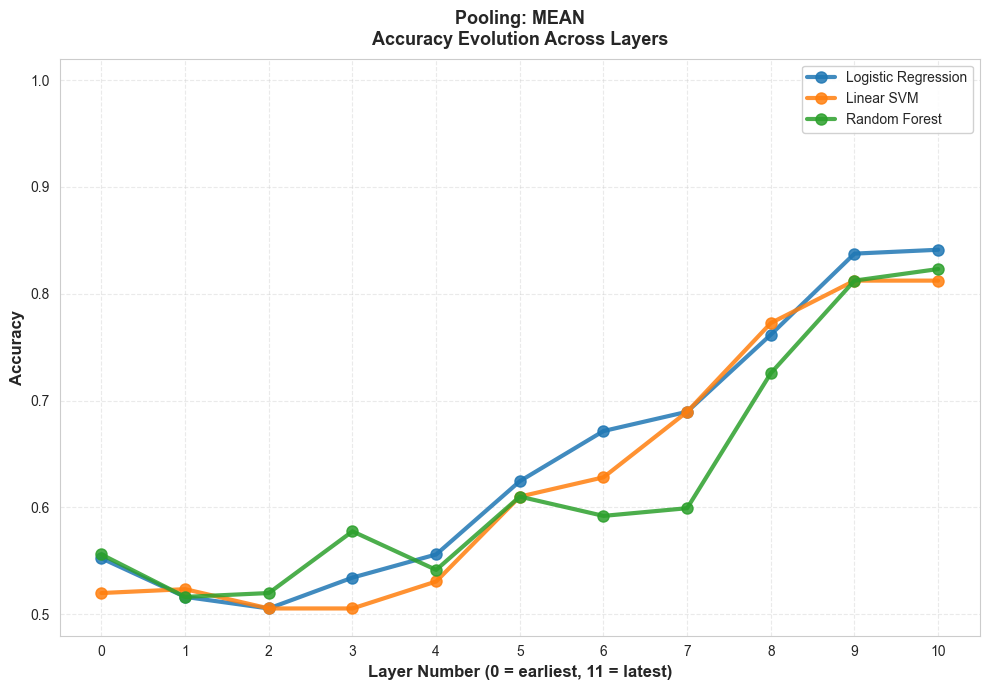

In [86]:
# 2. Line plot: Performance across ALL layers - MEAN pooling only
# This is the KEY visualization - shows trends clearly
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

pooling = 'mean'
pooling_results = results_df[results_df['pooling'] == pooling]

for clf_name in CLASSIFIERS.keys():
    clf_data = pooling_results[pooling_results['classifier'] == clf_name].sort_values('layer_num')
    ax.plot(clf_data['layer_num'], clf_data['accuracy'], 
            marker='o', label=clf_name, linewidth=3, markersize=8, alpha=0.85)

ax.set_xlabel('Layer Number (0 = earliest, 11 = latest)', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title(f'Pooling: MEAN\nAccuracy Evolution Across Layers', 
            fontsize=13, fontweight='bold', pad=10)
ax.legend(fontsize=10, loc='best', framealpha=0.9)
ax.set_xlim([-0.5, len(encoder_layers) - 0.5])  # Add padding to x-axis
ax.set_ylim([0.48, 1.02])  # Add padding to y-axis
ax.grid(True, alpha=0.4, linestyle='--')
ax.set_xticks(range(len(encoder_layers)))
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()


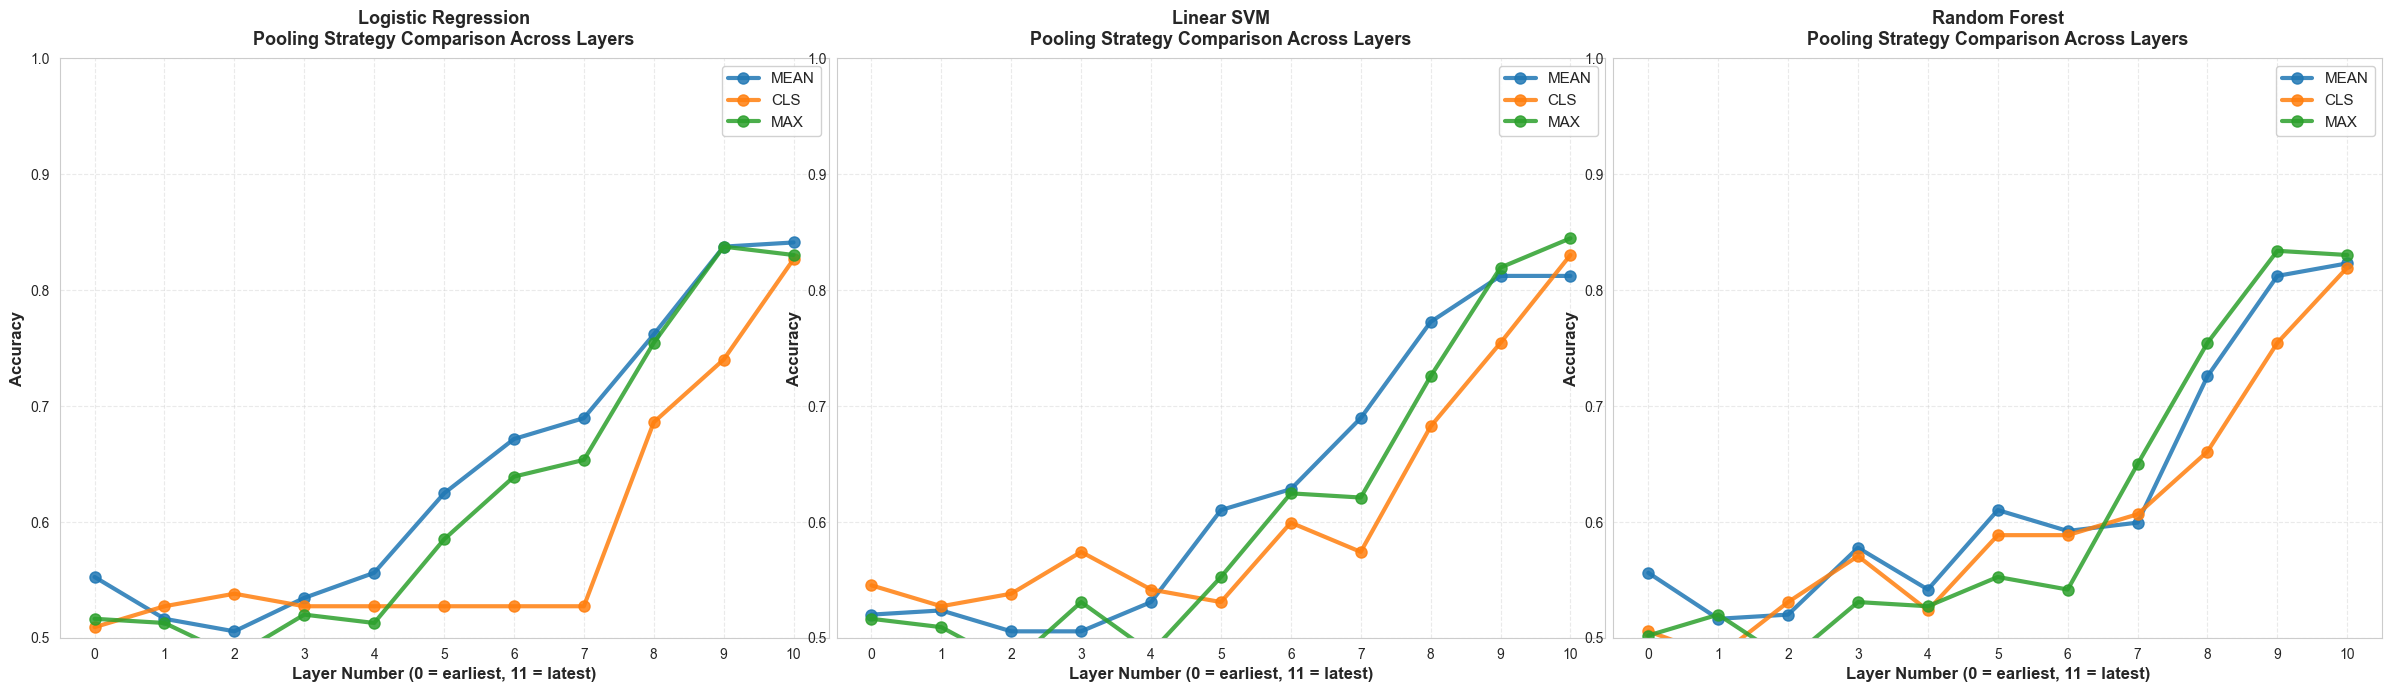

In [87]:
# 3. Combined line plot: All pooling strategies for each classifier
# Shows which pooling strategy is most consistent across layers
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

colors = {'mean': '#1f77b4', 'cls': '#ff7f0e', 'max': '#2ca02c'}

for idx, clf_name in enumerate(CLASSIFIERS.keys()):
    clf_results = results_df[results_df['classifier'] == clf_name]
    
    for pooling in POOLING_STRATEGIES:
        pooling_data = clf_results[clf_results['pooling'] == pooling].sort_values('layer_num')
        axes[idx].plot(pooling_data['layer_num'], pooling_data['accuracy'], 
                      marker='o', label=f'{pooling.upper()}', linewidth=3, markersize=8, 
                      alpha=0.85, color=colors[pooling])
    
    axes[idx].set_xlabel('Layer Number (0 = earliest, 11 = latest)', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    axes[idx].set_title(f'{clf_name}\nPooling Strategy Comparison Across Layers', 
                       fontsize=13, fontweight='bold', pad=10)
    axes[idx].legend(fontsize=11, loc='best', framealpha=0.9)
    axes[idx].set_ylim([0.5, 1.0])
    axes[idx].grid(True, alpha=0.4, linestyle='--')
    axes[idx].set_xticks(range(len(encoder_layers)))
    axes[idx].tick_params(axis='both', labelsize=10)

plt.tight_layout(pad=1.0, w_pad=-3.0, h_pad=0.2)
plt.show()

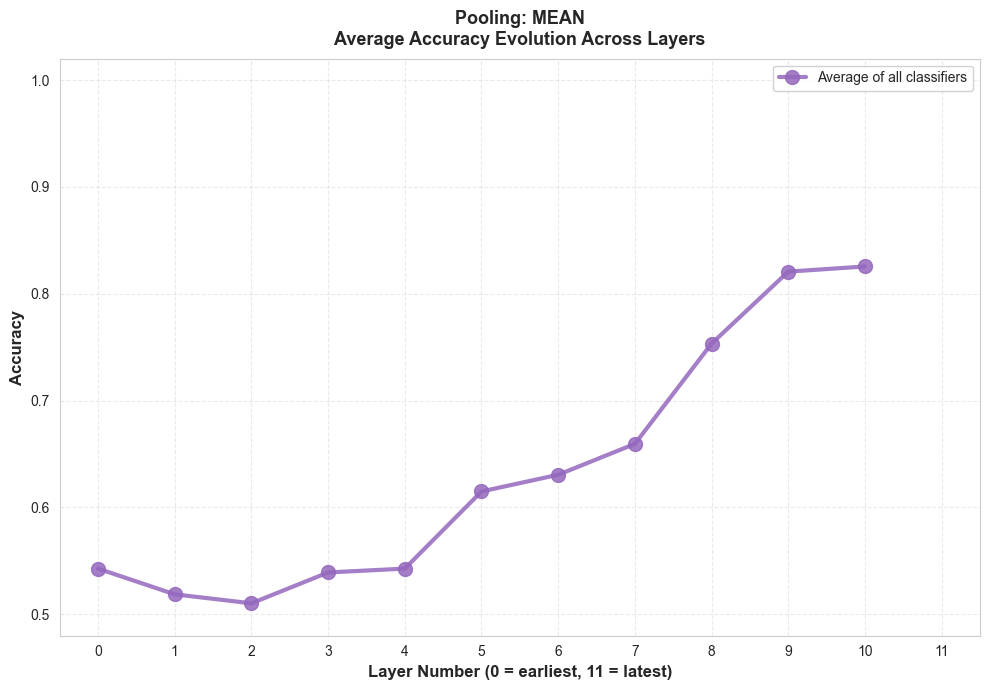

In [88]:
# Line plot: Average performance across classifiers - MEAN pooling only
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

pooling = 'mean'
pooling_results = results_df[results_df['pooling'] == pooling]

# Calculate average accuracy across all classifiers for each layer
avg_by_layer = pooling_results.groupby('layer_num')['accuracy'].mean().reset_index()

ax.plot(avg_by_layer['layer_num'], avg_by_layer['accuracy'], 
        marker='o', label='Average of all classifiers', linewidth=3, markersize=10, 
        alpha=0.85, color='#9467bd')

ax.set_xlabel('Layer Number (0 = earliest, 11 = latest)', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title(f'Pooling: MEAN\nAverage Accuracy Evolution Across Layers', 
            fontsize=13, fontweight='bold', pad=10)
ax.legend(fontsize=10, loc='best', framealpha=0.9)
ax.set_xlim([-0.5, 11.5])  # From -0.5 to 11.5 to include all layers (0-11)
ax.set_ylim([0.48, 1.02])  # Add padding to y-axis
ax.grid(True, alpha=0.4, linestyle='--')
ax.set_xticks(range(12))  # 0 to 11
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()


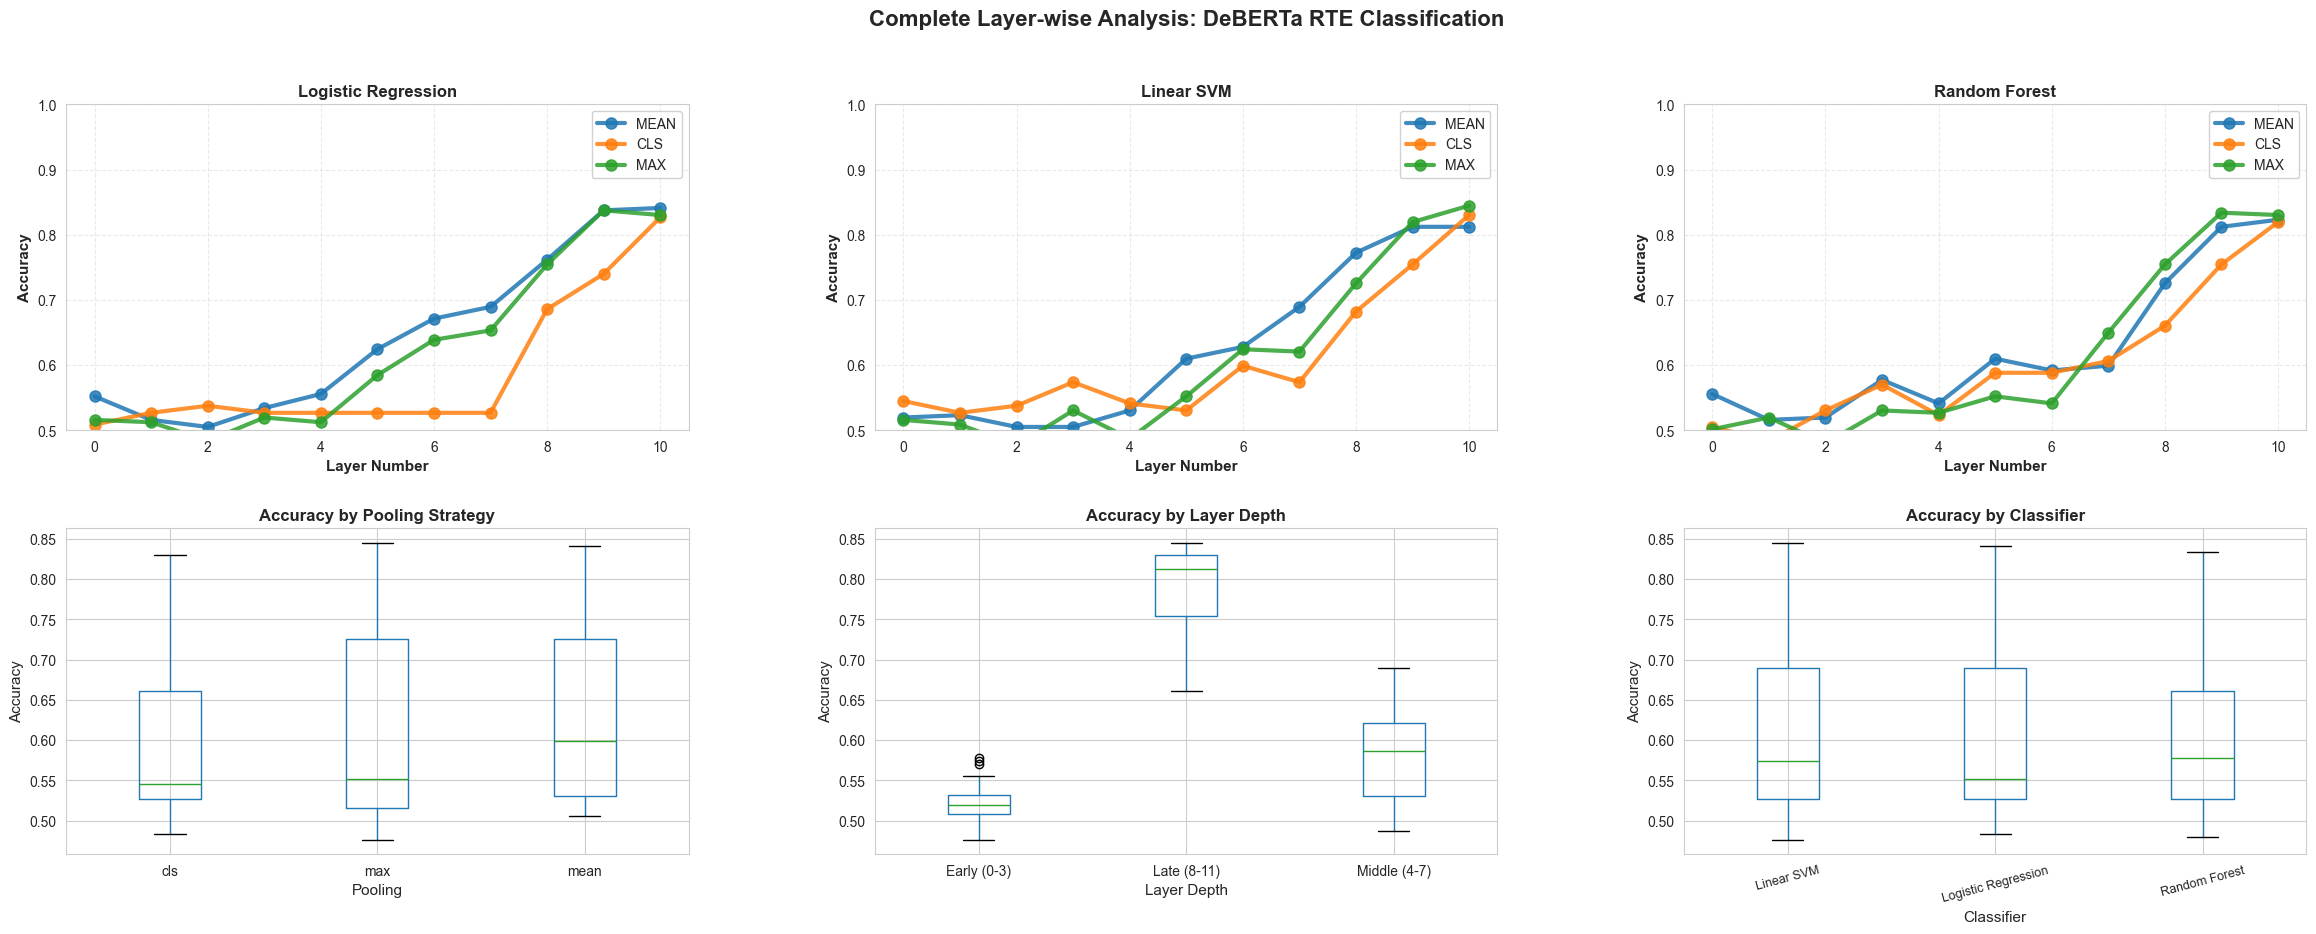

In [89]:
# 4. MEGA PLOT: All results in one comprehensive visualization
# This shows everything at once - best for understanding overall trends
fig = plt.figure(figsize=(28, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# Top row: Line plots for each classifier showing all pooling strategies
for idx, clf_name in enumerate(CLASSIFIERS.keys()):
    ax = fig.add_subplot(gs[0, idx])
    clf_results = results_df[results_df['classifier'] == clf_name]
    
    colors = {'mean': '#1f77b4', 'cls': '#ff7f0e', 'max': '#2ca02c'}
    for pooling in POOLING_STRATEGIES:
        pooling_data = clf_results[clf_results['pooling'] == pooling].sort_values('layer_num')
        ax.plot(pooling_data['layer_num'], pooling_data['accuracy'], 
                marker='o', label=f'{pooling.upper()}', linewidth=3, markersize=8, 
                alpha=0.85, color=colors[pooling])
    
    ax.set_xlabel('Layer Number', fontsize=11, fontweight='bold')
    ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
    ax.set_title(f'{clf_name}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10, loc='best', framealpha=0.9)
    ax.set_ylim([0.5, 1.0])
    ax.grid(True, alpha=0.4, linestyle='--')
    ax.set_xticks(range(0, len(encoder_layers), 2))  # Show every 2nd tick
    ax.tick_params(axis='both', labelsize=10)

# Bottom row: Box plots for overall distributions
# By pooling
ax1 = fig.add_subplot(gs[1, 0])
results_df.boxplot(column='accuracy', by='pooling', ax=ax1)
ax1.set_title('Accuracy by Pooling Strategy', fontsize=12, fontweight='bold')
ax1.set_xlabel('Pooling', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.get_figure().suptitle('')
ax1.tick_params(axis='both', labelsize=10)

# By layer depth category
ax2 = fig.add_subplot(gs[1, 1])
results_df['layer_depth'] = results_df['layer_num'].apply(
    lambda x: 'Early (0-3)' if x < 4 else ('Middle (4-7)' if x < 8 else 'Late (8-11)')
)
results_df.boxplot(column='accuracy', by='layer_depth', ax=ax2)
ax2.set_title('Accuracy by Layer Depth', fontsize=12, fontweight='bold')
ax2.set_xlabel('Layer Depth', fontsize=11)
ax2.set_ylabel('Accuracy', fontsize=11)
ax2.get_figure().suptitle('')
ax2.tick_params(axis='both', labelsize=10)

# By classifier
ax3 = fig.add_subplot(gs[1, 2])
results_df.boxplot(column='accuracy', by='classifier', ax=ax3)
ax3.set_title('Accuracy by Classifier', fontsize=12, fontweight='bold')
ax3.set_xlabel('Classifier', fontsize=11)
ax3.set_ylabel('Accuracy', fontsize=11)
ax3.get_figure().suptitle('')
ax3.tick_params(axis='x', labelsize=9, rotation=15)
ax3.tick_params(axis='y', labelsize=10)

plt.suptitle('Complete Layer-wise Analysis: DeBERTa RTE Classification', 
             fontsize=16, fontweight='bold', y=0.995)
plt.show()

## Layer Depth Analysis

Let's analyze how performance changes across layer depth (early, middle, late layers).


PERFORMANCE BY LAYER DEPTH
              accuracy  f1_score
layer_depth                     
Late (8-11)   0.784597  0.784686
Middle (4-7)  0.581929  0.557451
Early (0-3)   0.522363  0.510158


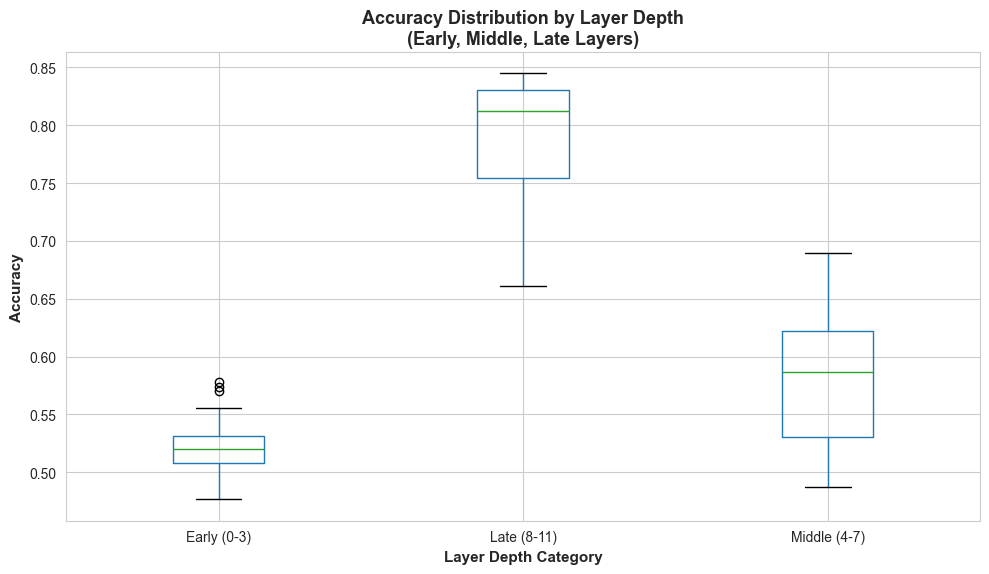

In [90]:
# Categorize layers by depth
def categorize_layer_depth(layer_num, total_layers=12):
    if layer_num < total_layers / 3:
        return 'Early (0-3)'
    elif layer_num < 2 * total_layers / 3:
        return 'Middle (4-7)'
    else:
        return 'Late (8-11)'

results_df['layer_depth'] = results_df['layer_num'].apply(categorize_layer_depth)

# Average performance by depth category
depth_summary = results_df.groupby('layer_depth')[['accuracy', 'f1_score']].mean().sort_values('accuracy', ascending=False)
print("\n" + "="*70)
print("PERFORMANCE BY LAYER DEPTH")
print("="*70)
print(depth_summary)

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
results_df.boxplot(column='accuracy', by='layer_depth', ax=ax)
ax.set_title('Accuracy Distribution by Layer Depth\n(Early, Middle, Late Layers)', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Layer Depth Category', fontsize=11, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax.get_figure().suptitle('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Detailed Analysis: Best Configuration

In [91]:
# Find best configuration
best_config = results_df.loc[results_df['accuracy'].idxmax()]

print("="*70)
print("BEST CONFIGURATION")
print("="*70)
print(f"Pooling: {best_config['pooling']}")
print(f"Layer: {best_config['layer']} (layer number {best_config['layer_num']})")
print(f"Classifier: {best_config['classifier']}")
print(f"Accuracy: {best_config['accuracy']:.4f}")
print(f"F1 Score: {best_config['f1_score']:.4f}")
print(f"Feature dimension: {int(best_config['feature_dim'])}")

BEST CONFIGURATION
Pooling: max
Layer: layer_10 (layer number 10)
Classifier: Linear SVM
Accuracy: 0.8448
F1 Score: 0.8448
Feature dimension: 768



CLASSIFICATION REPORT (Best Configuration)
                precision    recall  f1-score   support

Not Entailment       0.86      0.84      0.85       146
    Entailment       0.83      0.85      0.84       131

      accuracy                           0.84       277
     macro avg       0.84      0.84      0.84       277
  weighted avg       0.85      0.84      0.84       277



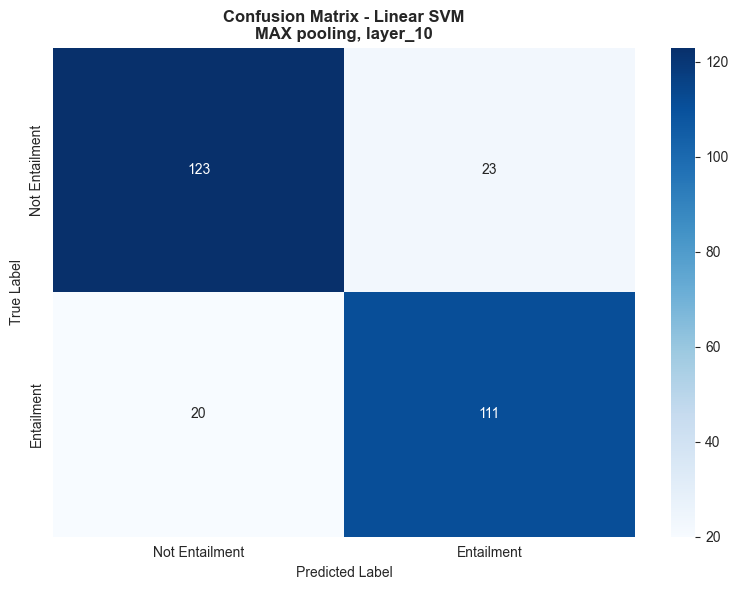

In [92]:
# Train best model again and show detailed metrics
best_pooling = best_config['pooling']
best_layer = best_config['layer']
best_clf_name = best_config['classifier']

# Get features
train_features_dict, train_labels = features_by_pooling[best_pooling]['train']
val_features_dict, val_labels = features_by_pooling[best_pooling]['val']

X_train = train_features_dict[best_layer]
y_train = train_labels
X_val = val_features_dict[best_layer]
y_val = val_labels

# Train best classifier
from sklearn.base import clone
best_clf = clone(CLASSIFIERS[best_clf_name])
best_clf.fit(X_train, y_train)
y_pred = best_clf.predict(X_val)

# Classification report
print("\n" + "="*70)
print("CLASSIFICATION REPORT (Best Configuration)")
print("="*70)
print(classification_report(y_val, y_pred, target_names=['Not Entailment', 'Entailment']))

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Entailment', 'Entailment'],
            yticklabels=['Not Entailment', 'Entailment'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title(f'Confusion Matrix - {best_clf_name}\n{best_pooling.upper()} pooling, {best_layer}', 
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Compare with Full Model Performance

Let's see how our simple classifiers on intermediate layers compare to the fine-tuned model's full performance.

In [93]:
# Evaluate the full fine-tuned model on validation set
from torch.utils.data import DataLoader
import torch

model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Tokenize validation set
val_encodings = tokenizer(
    [x['sentence1'] for x in val_dataset],
    [x['sentence2'] for x in val_dataset],
    padding=True,
    truncation=True,
    max_length=MAX_LENGTH,
    return_tensors='pt'
)

# Get predictions
with torch.no_grad():
    outputs = model(
        input_ids=val_encodings['input_ids'].to(device),
        attention_mask=val_encodings['attention_mask'].to(device)
    )
    full_model_preds = outputs.logits.argmax(dim=-1).cpu().numpy()

# Compute metrics
full_model_accuracy = accuracy_score(val_labels, full_model_preds)
full_model_f1 = f1_score(val_labels, full_model_preds, average='weighted')

print("="*70)
print("FULL FINE-TUNED MODEL PERFORMANCE")
print("="*70)
print(f"Accuracy: {full_model_accuracy:.4f}")
print(f"F1 Score: {full_model_f1:.4f}")

print("\n" + "="*70)
print("COMPARISON")
print("="*70)
print(f"Full model accuracy: {full_model_accuracy:.4f}")
print(f"Best layer classifier accuracy: {best_config['accuracy']:.4f}")
print(f"Difference: {full_model_accuracy - best_config['accuracy']:.4f}")
print(f"Relative performance: {(best_config['accuracy'] / full_model_accuracy) * 100:.2f}%")

FULL FINE-TUNED MODEL PERFORMANCE
Accuracy: 0.8267
F1 Score: 0.8268

COMPARISON
Full model accuracy: 0.8267
Best layer classifier accuracy: 0.8448
Difference: -0.0181
Relative performance: 102.18%


## Save Results

In [94]:
# Save results DataFrame
output_dir = REPO_ROOT / "data" / "layer_classifier_results"
output_dir.mkdir(parents=True, exist_ok=True)

results_df.to_csv(output_dir / "deberta_rte_all_layers_classifier_results.csv", index=False)
print(f"✓ Results saved to: {output_dir / 'deberta_rte_all_layers_classifier_results.csv'}")

# Save summary statistics
summary = {
    'best_config': best_config.to_dict(),
    'full_model_accuracy': float(full_model_accuracy),
    'full_model_f1': float(full_model_f1),
    'avg_by_pooling': results_df.groupby('pooling')[['accuracy', 'f1_score']].mean().to_dict(),
    'avg_by_layer': results_df.groupby('layer')[['accuracy', 'f1_score']].mean().to_dict(),
    'avg_by_layer_depth': results_df.groupby('layer_depth')[['accuracy', 'f1_score']].mean().to_dict(),
    'avg_by_classifier': results_df.groupby('classifier')[['accuracy', 'f1_score']].mean().to_dict(),
}

import json
with open(output_dir / "summary_all_layers.json", 'w') as f:
    json.dump(summary, f, indent=2)
print(f"✓ Summary saved to: {output_dir / 'summary_all_layers.json'}")

✓ Results saved to: /Users/insider/ITA/unstructured-data-metafeatures/data/layer_classifier_results/deberta_rte_all_layers_classifier_results.csv
✓ Summary saved to: /Users/insider/ITA/unstructured-data-metafeatures/data/layer_classifier_results/summary_all_layers.json


## Conclusions

This notebook analyzed the discriminative power of **ALL encoder layers** in DeBERTa-v3-base for RTE classification.

Key findings:
1. **Layer evolution**: How discriminative power changes from early (0-3) to middle (4-7) to late (8-11) layers
2. **Best layer**: Which specific layer provides the best features for classification
3. **Pooling strategy**: Which pooling method (mean/cls/max) works best across all layers
4. **Classifier type**: Which simple classifier achieves the best performance
5. **Gap to full model**: How much performance is lost by using simpler classifiers on intermediate layers

Key insights to look for:
- Do later layers always perform better, or do some earlier layers have good discriminative features?
- Is there a plateau effect where adding more layers doesn't improve performance?
- How consistent is the best pooling strategy across different layers?

Check the visualizations above for detailed analysis.